In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

try:
    ee.Initialize(project='replicating-paper')
    print("Google Earth Engine Initialized successfully.")
except Exception as e:
    print("Authenticating...")
    ee.Authenticate()
    ee.Initialize()
    print("Google Earth Engine Initialized successfully (after auth).")

roi = ee.Geometry.Rectangle([77.17, 28.52, 77.18, 28.54])

# 3-year window to create a robust "Synthetic Year" free of clouds
START_DATE = '2022-01-01'
END_DATE = '2024-12-31'
SCALE = 10

print(f"Target Region: Sanjay Van")
print(f"Time Window: {START_DATE} to {END_DATE}")
print(f"Analysis Scale: {SCALE} meters")

Map = geemap.Map(location=[28.53, 77.175], zoom=14)
Map.addLayer(roi, {'color': 'red'}, 'Sanjay Van ROI')
Map

Google Earth Engine Initialized successfully.
Target Region: Sanjay Van
Time Window: 2022-01-01 to 2024-12-31
Analysis Scale: 10 meters


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [3]:
import math

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))

    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])

def add_seasonality_vars(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    date = image.date()
    years = date.difference(ee.Date(START_DATE), 'year')
    time_radians = years.multiply(2 * math.pi)

    cos = ee.Image(time_radians).cos().rename('cos')
    sin = ee.Image(time_radians).sin().rename('sin')

    return image.addBands([ndvi, cos, sin, ee.Image.constant(1).rename('constant')])

print("Loading Sentinel-2 Archive (2022-2024)...")
s2_collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")\
    .filterBounds(roi)\
    .filterDate(START_DATE, END_DATE)\
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))\
    .map(mask_s2_clouds)\
    .map(add_seasonality_vars)

print("Generating Static Composite (The 'Camera')...")
static_composite = s2_collection.select(['B4', 'B3', 'B2', 'B8', 'B11'])\
    .median()\
    .rename(['Red_Median', 'Green_Median', 'Blue_Median', 'NIR_Median', 'SWIR_Median'])\
    .clip(roi)

print("Calculating Phenology Harmonics (The 'Heartbeat')...")
harmonics = s2_collection.select(['constant', 'cos', 'sin', 'NDVI'])\
    .reduce(ee.Reducer.linearRegression(3, 1))

coeffs = harmonics.select('coefficients')\
    .arrayProject([0])\
    .arrayFlatten([['constant', 'cos_coeff', 'sin_coeff']])

ndvi_mean = coeffs.select('constant').rename('NDVI_Mean')
ndvi_amp = coeffs.select('cos_coeff').hypot(coeffs.select('sin_coeff')).rename('NDVI_Amp')
ndvi_phase = coeffs.select('sin_coeff').atan2(coeffs.select('cos_coeff')).rename('NDVI_Phase')

optical_stack = ee.Image.cat([static_composite, ndvi_mean, ndvi_amp, ndvi_phase]).clip(roi)

print("Optical Stack Ready.")
print("Bands:", optical_stack.bandNames().getInfo())

Map.centerObject(roi, 15)
Map.addLayer(ndvi_amp, {'min': 0, 'max': 0.5, 'palette': ['black', 'white']}, 'NDVI Amplitude (Breathing)')
Map

Loading Sentinel-2 Archive (2022-2024)...
Generating Static Composite (The 'Camera')...
Calculating Phenology Harmonics (The 'Heartbeat')...
Optical Stack Ready.
Bands: ['Red_Median', 'Green_Median', 'Blue_Median', 'NIR_Median', 'SWIR_Median', 'NDVI_Mean', 'NDVI_Amp', 'NDVI_Phase']


Map(center=[28.529999775258553, 77.17499999999156], controls=(WidgetControl(options=['position', 'transparent_…

In [4]:

# Is it a Tree (>5m) or a Bush (<2m)
canopy_height = ee.Image("users/nlang/ETH_GlobalCanopyHeight_2020_10m_v1")\
    .select('b1')\
    .rename('Canopy_Height')\
    .clip(roi)\
    .unmask(0) # Fill gaps with 0 height

# Is it smooth (Grass/Path) or rough (Scrub)?
print("Loading Structure: Sentinel-1 Radar...")
s1 = ee.ImageCollection("COPERNICUS/S1_GRD")\
    .filterBounds(roi)\
    .filterDate(START_DATE, END_DATE)\
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))\
    .filter(ee.Filter.eq('instrumentMode', 'IW'))

s1_vh = s1.select('VH').mean().rename('S1_VH_Mean').clip(roi)

# Is it on a Ridge or in a Valley?
print("Loading Context: Elevation & Slope...")
nasa_dem = ee.Image("NASA/NASADEM_HGT/001").clip(roi)
elevation = nasa_dem.select('elevation').rename('Elevation')
slope = ee.Terrain.slope(elevation).rename('Slope')

master_stack = ee.Image.cat([optical_stack, canopy_height, s1_vh, elevation, slope])

print("\n--- MASTER STACK COMPLETE ---")
print("Total Bands:", master_stack.bandNames().size().getInfo())
print("Band Names:", master_stack.bandNames().getInfo())

vis_params = {
    'bands': ['NDVI_Amp', 'Canopy_Height', 'S1_VH_Mean'],
    'min': [0.05, 0, -25],
    'max': [0.4, 15, -10],
    'gamma': [1, 1, 1]
}
Map.addLayer(master_stack, vis_params, 'RGB: Seasonality/Height/Texture')
Map

Loading Structure: Sentinel-1 Radar...
Loading Context: Elevation & Slope...

--- MASTER STACK COMPLETE ---
Total Bands: 12
Band Names: ['Red_Median', 'Green_Median', 'Blue_Median', 'NIR_Median', 'SWIR_Median', 'NDVI_Mean', 'NDVI_Amp', 'NDVI_Phase', 'Canopy_Height', 'S1_VH_Mean', 'Elevation', 'Slope']


Map(center=[28.529999775258553, 77.17499999999156], controls=(WidgetControl(options=['position', 'transparent_…

In [5]:

selected_bands = [
    'NDVI_Amp',         # Phenology: Seasonality
    'NDVI_Phase',       # Phenology: Timing
    'NDVI_Mean',        # Phenology: Biomass
    'Canopy_Height',    # Structure: Height
    'S1_VH_Mean',       # Structure: Texture
    'Elevation',        # Context: Topo
    'Red_Median',       # Static: Path Color
    'NIR_Median',       # Static: Vegetation Density
    'SWIR_Median'       # Static: Urban/Soil
]

input_image = master_stack.select(selected_bands)

print("Applying Log Transformation to skew-prone bands...")
skewed_bands = ['Canopy_Height', 'Red_Median', 'SWIR_Median']

def deskew(image):
    processed = image
    for band in skewed_bands:
        log_band = image.select(band).add(1).log10().rename(f'{band}_Log')
        processed = processed.addBands(log_band)
    return processed

deskewed_stack = deskew(input_image)

# Update band list to use the Log versions
clustering_bands = [
    'NDVI_Amp', 'NDVI_Phase', 'NDVI_Mean',
    'Canopy_Height_Log', 'S1_VH_Mean', 'Elevation',
    'Red_Median_Log', 'NIR_Median', 'SWIR_Median_Log'
]
final_stack = deskewed_stack.select(clustering_bands)

stats = final_stack.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True),
    geometry=roi,
    scale=10,
    bestEffort=True,
    maxPixels=1e9
)

mean_keys = [b + '_mean' for b in clustering_bands]
std_keys = [b + '_stdDev' for b in clustering_bands]

mean_img = stats.toImage(mean_keys).rename(clustering_bands)
std_img = stats.toImage(std_keys).rename(clustering_bands).max(1e-6)

normalized_stack = final_stack.subtract(mean_img).divide(std_img)

print("\n--- NORMALIZATION COMPLETE ---")
print("Bands for Clustering:", normalized_stack.bandNames().getInfo())

Applying Log Transformation to skew-prone bands...

--- NORMALIZATION COMPLETE ---
Bands for Clustering: ['NDVI_Amp', 'NDVI_Phase', 'NDVI_Mean', 'Canopy_Height_Log', 'S1_VH_Mean', 'Elevation', 'Red_Median_Log', 'NIR_Median', 'SWIR_Median_Log']


In [6]:

print("Running SNIC Segmentation...")

# size=8 (80m)
seeds = ee.Algorithms.Image.Segmentation.seedGrid(8)

snic = ee.Algorithms.Image.Segmentation.SNIC(
    image=normalized_stack,
    compactness=0.1,
    connectivity=8,
    neighborhoodSize=128,
    seeds=seeds
)

# We discard the raw pixels and keep these "Stand Averages."
mean_band_names = [b + '_mean' for b in clustering_bands]
snic_means = snic.select(mean_band_names)

object_stack = snic_means.rename(clustering_bands)

print("Segmentation Complete.")
print("The image is now composed of 'Superpixels' (Stands) instead of raw pixels.")

print("Displaying Segments...")
snic_id = snic.select('clusters').randomVisualizer()
Map.addLayer(snic_id, {}, 'SNIC Segments (Objects)')
Map

Running SNIC Segmentation...
Segmentation Complete.
The image is now composed of 'Superpixels' (Stands) instead of raw pixels.
Displaying Segments...


Map(center=[28.529999775258553, 77.17499999999156], controls=(WidgetControl(options=['position', 'transparent_…

In [7]:
from IPython.display import Image

print("Running SNIC Segmentation...")

seeds = ee.Algorithms.Image.Segmentation.seedGrid(8)

snic = ee.Algorithms.Image.Segmentation.SNIC(
    image=normalized_stack,
    compactness=0.1,
    connectivity=8,
    neighborhoodSize=128,
    seeds=seeds
)

mean_band_names = [b + '_mean' for b in clustering_bands]
snic_means = snic.select(mean_band_names)
object_stack = snic_means.rename(clustering_bands)

print("Segmentation Complete.")

print("Generating Static Thumbnail of Segments...")

snic_vis = snic.select('clusters').randomVisualizer().select([0, 1, 2])

vis_params = {
    'dimensions': 800,
    'region': roi,
    'format': 'png'
}

thumb_url = snic_vis.getThumbURL(vis_params)
display(Image(url=thumb_url))

Running SNIC Segmentation...
Segmentation Complete.
Generating Static Thumbnail of Segments...


In [8]:
print(thumb_url)

https://earthengine.googleapis.com/v1/projects/replicating-paper/thumbnails/a6461b9e1ccfca27814acdf5993cbd64-e10c5bc2be5985929bca6783a03fb3f0:getPixels


Training K-Means Clusterer (k=5)...
Clustering Complete. Calculating Heartbeats...

--- CLUSTER INTERPRETATION ---
Cluster 0: Height=-1.0m, Amp=-1.02, Mean=-1.73
Cluster 1: Height=-0.2m, Amp=1.18, Mean=0.43
Cluster 2: Height=-0.9m, Amp=-0.13, Mean=-0.67
Cluster 3: Height=4.2m, Amp=0.12, Mean=0.56
Cluster 4: Height=4.3m, Amp=-0.07, Mean=0.62


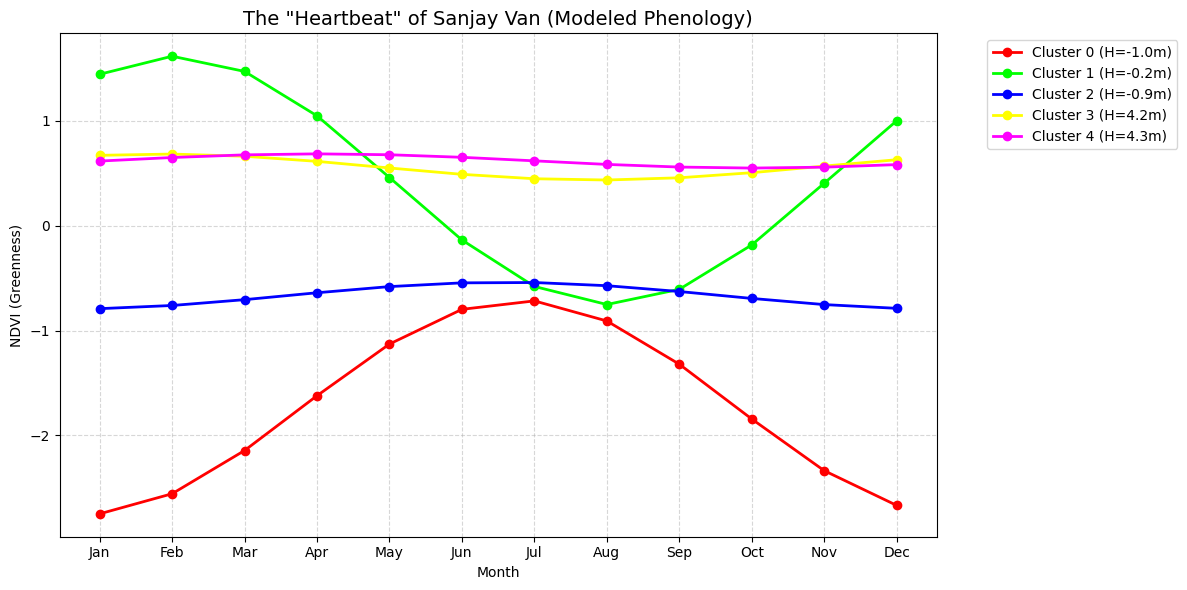

Generating Cluster Map...


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Training K-Means Clusterer (k=5)...")

training_data = object_stack.sample(
    region=roi,
    scale=10,
    numPixels=5000,
    geometries=True
)

clusterer = ee.Clusterer.wekaKMeans(5).train(training_data)

cluster_result = object_stack.cluster(clusterer).rename('Cluster_ID')

print("Clustering Complete. Calculating Heartbeats...")

# Define the specific 5 bands we want to analyze (The "Genes")
gene_bands = ['NDVI_Mean', 'NDVI_Amp', 'NDVI_Phase', 'Canopy_Height_Log', 'S1_VH_Mean']

# Create a combined image: 5 Data Bands + 1 Cluster Band
combined = object_stack.select(gene_bands).addBands(cluster_result)

# This matches our 6-band image exactly.
reducer = ee.Reducer.mean().repeat(5).group(
    groupField=5,   # The 6th band (index 5) is 'Cluster_ID'
    groupName='Cluster_ID'
)

# Run the stats
summary = combined.reduceRegion(
    reducer=reducer,
    geometry=roi,
    scale=10,
    bestEffort=True
).get('groups').getInfo()

months = np.arange(1, 13)
time_radians = (months - 0.5) / 12 * 2 * np.pi
colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF'] # Red, Green, Blue, Yellow, Magenta

plt.figure(figsize=(12, 6))

print("\n--- CLUSTER INTERPRETATION ---")

for item in summary:
    c_id = int(item['Cluster_ID'])

    stats = item['mean']

    mean = stats[0]
    amp = stats[1]
    phase = stats[2]
    height_log = stats[3]
    s1_vh = stats[4]

    height = (10**height_log) - 1

    curve = mean + amp * np.cos(time_radians - phase)

    label = f"Cluster {c_id} (H={height:.1f}m)"
    plt.plot(months, curve, marker='o', linewidth=2, label=label, color=colors[c_id])

    print(f"Cluster {c_id}: Height={height:.1f}m, Amp={amp:.2f}, Mean={mean:.2f}")


plt.title('The "Heartbeat" of Sanjay Van (Modeled Phenology)', fontsize=14)
plt.ylabel('NDVI (Greenness)')
plt.xlabel('Month')
plt.xticks(months, ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Show the Map
print("Generating Cluster Map...")
vis_params = {
    'min': 0, 'max': 4,
    'palette': colors,
    'dimensions': 800,
    'region': roi,
    'format': 'png'
}
thumb_url = cluster_result.getThumbURL(vis_params)
display(Image(url=thumb_url))

In [10]:
import pandas as pd

print("Generating Stand Profiles based on Structure & Behavior...")

raw_bands = ['NDVI_Mean', 'NDVI_Amp', 'Canopy_Height', 'S1_VH_Mean']
raw_image = master_stack.select(raw_bands).addBands(cluster_result)

raw_stats = raw_image.reduceRegion(
    reducer=ee.Reducer.mean().repeat(4).group(
        groupField=4,
        groupName='Cluster_ID'
    ),
    geometry=roi,
    scale=10,
    bestEffort=True
).get('groups').getInfo()

print("\n" + "="*80)
print(f"{'ID':<3} | {'HEIGHT':<12} | {'SEASONALITY':<15} | {'DENSITY':<12} | {'FUNCTIONAL TYPE DESCRIPTION'}")
print("="*80)

for item in raw_stats:
    c_id = int(item['Cluster_ID'])
    means = item['mean']

    ndvi_mean = means[0]
    ndvi_amp = means[1]
    height = means[2]


    if height < 2: h_desc = "Low/Ground"
    elif height < 5: h_desc = "Shrub/Bush"
    else: h_desc = "Tree Canopy"

    if ndvi_amp > 0.12: s_desc = "Seasonal (Deciduous)"
    else: s_desc = "Stable (Evergreen)"

    if ndvi_mean < 0.2: d_desc = "Sparse/Bare"
    else: d_desc = "Dense Green"

    if h_desc == "Low/Ground" and d_desc == "Sparse/Bare":
        label = "Non-Vegetated (Path/Built)"
    elif h_desc == "Low/Ground" and s_desc == "Seasonal (Deciduous)":
        label = "Seasonal Grass/Herb"
    elif h_desc == "Tree Canopy" and s_desc == "Stable (Evergreen)":
        label = "Tall Evergreen Stand"
    elif h_desc == "Tree Canopy" and s_desc == "Seasonal (Deciduous)":
        label = "Tall Deciduous Stand"
    else:
        label = f"Mixed {h_desc}"

    # Print Row
    print(f"{c_id:<3} | {height:<5.1f} meters  | {ndvi_amp:<5.3f} (Amp)    | {ndvi_mean:<5.2f} (NDVI)  | {label}")

print("="*80)


Generating Stand Profiles based on Structure & Behavior...

ID  | HEIGHT       | SEASONALITY     | DENSITY      | FUNCTIONAL TYPE DESCRIPTION
0   | 0.0   meters  | 0.028 (Amp)    | 0.08  (NDVI)  | Non-Vegetated (Path/Built)
1   | 5.0   meters  | 0.106 (Amp)    | 0.61  (NDVI)  | Mixed Shrub/Bush
2   | 1.4   meters  | 0.060 (Amp)    | 0.34  (NDVI)  | Mixed Low/Ground
3   | 12.0  meters  | 0.068 (Amp)    | 0.65  (NDVI)  | Tall Evergreen Stand
4   | 12.4  meters  | 0.062 (Amp)    | 0.66  (NDVI)  | Tall Evergreen Stand


In [11]:
!pip install rasterio

import rasterio
from rasterio.plot import show
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np

print("Mounting Google Drive...")
drive.mount('/content/drive')

tif_path = '/content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif'

print(f"Target File: {tif_path}")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Target File: /content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif


Reading Drone GeoTIFF from: /content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif
Original Projection: EPSG:32643
Converted Bounds: 77.1730, 28.5278, 77.1756, 28.5303


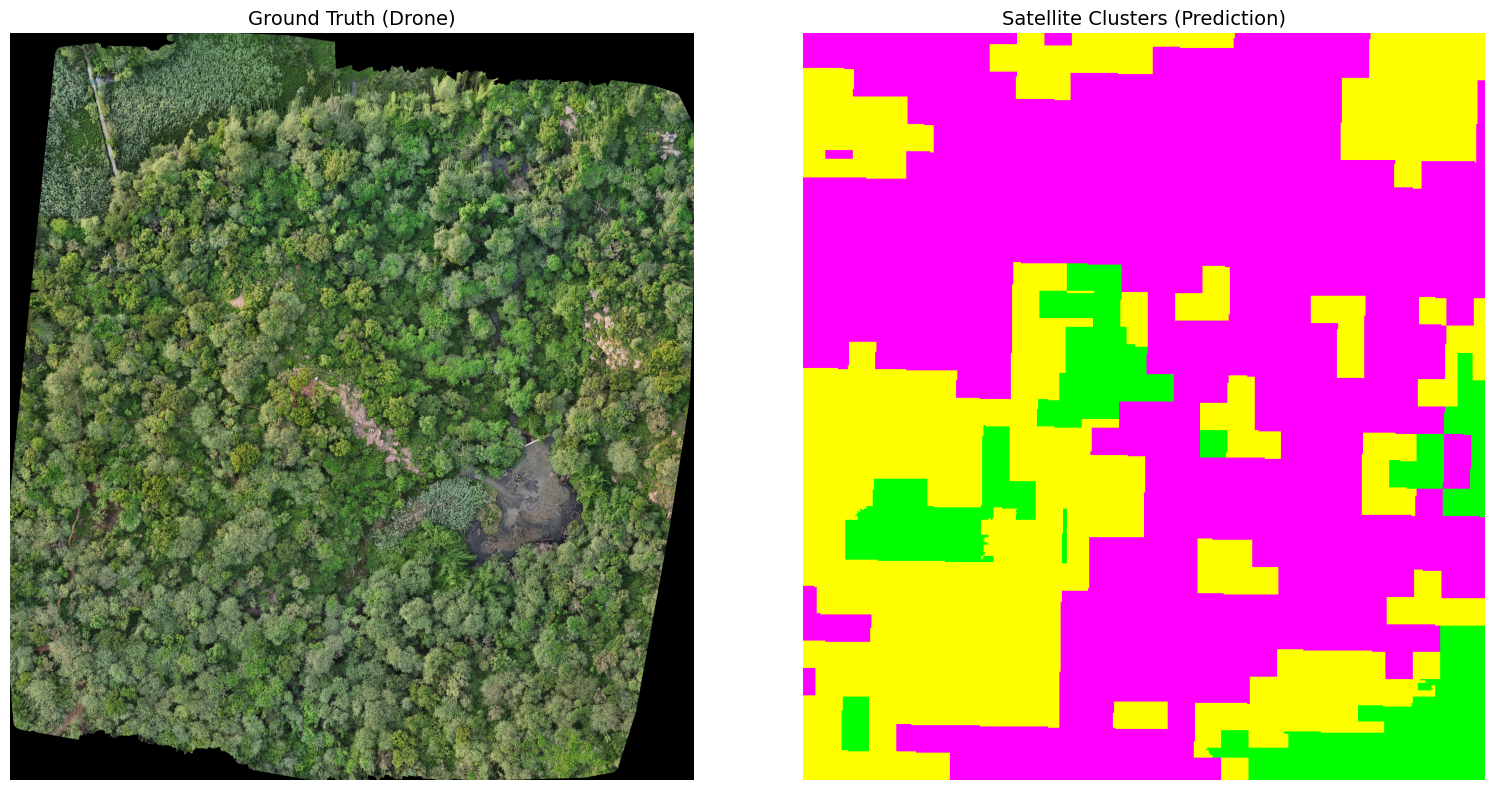


SUCCESS!
Left: Your Drone Image (Real Trees)
Right: Satellite Prediction (Blocks)
   - Look for MAGENTA/YELLOW blocks matching your Green Trees.
   - Look for RED blocks matching the Paths/Dirt.


In [12]:
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
import ee

def visualize_overlap(tif_path, gee_image):
    try:
        print(f"Reading Drone GeoTIFF from: {tif_path}")
        with rasterio.open(tif_path) as src:

            if src.count >= 3:
                drone_img = src.read([1, 2, 3])
            else:
                drone_img = src.read(1)

            drone_plot = np.moveaxis(drone_img, 0, -1)
            if drone_plot.max() > 0:
                drone_plot = ((drone_plot - drone_plot.min()) / (drone_plot.max() - drone_plot.min()) * 255).astype(np.uint8)

            print(f"Original Projection: {src.crs}")

            left, bottom, right, top = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
            print(f"Converted Bounds: {left:.4f}, {bottom:.4f}, {right:.4f}, {top:.4f}")

            roi_coords = [
                [left, bottom],
                [right, bottom],
                [right, top],
                [left, top],
                [left, bottom] # Close the loop
            ]

            drone_roi = ee.Geometry.Polygon(roi_coords)


        colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF']

        vis_params = {
            'min': 0, 'max': 4,
            'palette': colors,
            'region': drone_roi.getInfo(), # <--- .getInfo() forces it to simple JSON text
            'dimensions': 600,             # Reduced slightly to be safe
            'format': 'png',
            'crs': 'EPSG:3857'             # Force Web Mercator projection for alignment
        }

        thumb_url = gee_image.getThumbURL(vis_params)

        plt.figure(figsize=(16, 8))

        plt.subplot(1, 2, 1)
        plt.imshow(drone_plot)
        plt.title("Ground Truth (Drone)", fontsize=14)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        sat_img = io.imread(thumb_url)
        plt.imshow(sat_img)
        plt.title("Satellite Clusters (Prediction)", fontsize=14)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        print("\nSUCCESS!")
        print("Left: Your Drone Image (Real Trees)")
        print("Right: Satellite Prediction (Blocks)")
        print("   - Look for MAGENTA/YELLOW blocks matching your Green Trees.")
        print("   - Look for RED blocks matching the Paths/Dirt.")

    except Exception as e:
        print(f"Error: {e}")

# Run the visualization
tif_path = '/content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif'
visualize_overlap(tif_path, cluster_result)

Reading Drone GeoTIFF: /content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif
Projection: EPSG:32643
Fetching aligned Satellite Map...


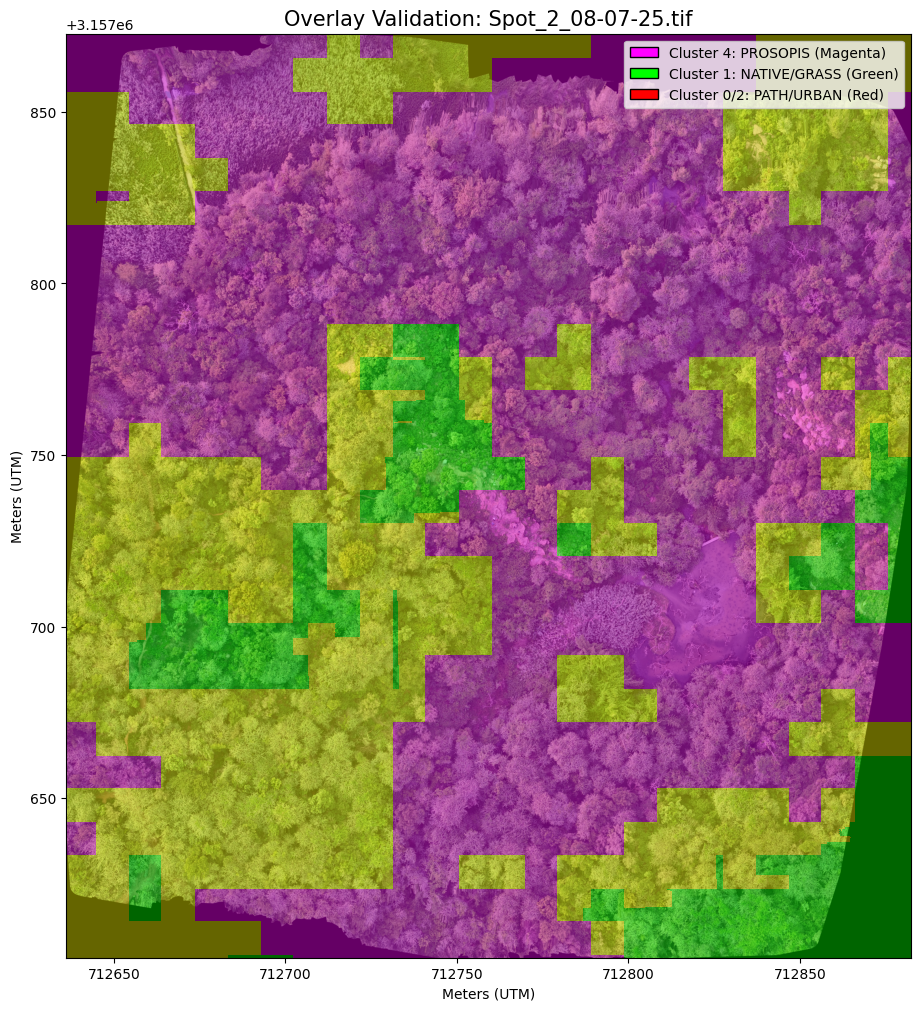

Done! You are looking at the Satellite AI 'painted' over your Drone reality.


In [13]:
# @title
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.transform import resize
import ee

def visualize_overlay(tif_path, gee_image):
    try:
        # 1. Open Drone Image
        print(f"Reading Drone GeoTIFF: {tif_path}")
        with rasterio.open(tif_path) as src:
            # Read RGB
            if src.count >= 3:
                drone_img = src.read([1, 2, 3])
            else:
                drone_img = src.read(1)

            # Normalize Drone Image
            drone_plot = np.moveaxis(drone_img, 0, -1)
            if drone_plot.max() > 0:
                drone_plot = ((drone_plot - drone_plot.min()) / (drone_plot.max() - drone_plot.min()) * 255).astype(np.uint8)

            # Get Native Bounds (UTM) & CRS
            native_bounds = src.bounds
            native_crs = src.crs.to_string() # e.g., 'EPSG:32643'
            print(f"Projection: {native_crs}")

            # 2. Prepare Region for GEE (Needs to be Lat/Lon)
            left, bottom, right, top = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)

            # Create GeoJSON Polygon for the request
            roi_coords = [[left, bottom], [right, bottom], [right, top], [left, top], [left, bottom]]
            drone_roi = ee.Geometry.Polygon(roi_coords)

        # 3. Fetch Satellite Map (Projected to Match Drone)
        print("Fetching aligned Satellite Map...")
        colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF']

        vis_params = {
            'min': 0, 'max': 4,
            'palette': colors,
            'region': drone_roi.getInfo(),
            'dimensions': 800,
            'format': 'png',
            'crs': native_crs
        }

        thumb_url = gee_image.getThumbURL(vis_params)
        sat_img = io.imread(thumb_url)

        # 4. Plot Overlay
        plt.figure(figsize=(12, 12))

        # Define the extent so Matplotlib knows where to place pixels (Left, Right, Bottom, Top)
        extent = [native_bounds.left, native_bounds.right, native_bounds.bottom, native_bounds.top]

        # Layer 1: Drone Image (Bottom)
        plt.imshow(drone_plot, extent=extent)

        # Layer 2: Satellite Clusters (Top, 40% Transparent)
        # We assume GEE returns the image roughly matching the bounds requested
        plt.imshow(sat_img, extent=extent, alpha=0.4, interpolation='nearest')

        plt.title(f"Overlay Validation: {tif_path.split('/')[-1]}", fontsize=15)
        plt.xlabel("Meters (UTM)")
        plt.ylabel("Meters (UTM)")

        # Legend (Manual)
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#FF00FF', edgecolor='k', label='Cluster 4: PROSOPIS (Magenta)'),
            Patch(facecolor='#00FF00', edgecolor='k', label='Cluster 1: NATIVE/GRASS (Green)'),
            Patch(facecolor='#FF0000', edgecolor='k', label='Cluster 0/2: PATH/URBAN (Red)'),
        ]
        plt.legend(handles=legend_elements, loc='upper right')

        plt.show()
        print("Done! You are looking at the Satellite AI 'painted' over your Drone reality.")

    except Exception as e:
        print(f"Error: {e}")

# Run Overlay
tif_path = '/content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif'
visualize_overlay(tif_path, cluster_result)